#**Actividad: DASHboards y Plotly**

Maria Fernanda Barba De Los Santos A01657868

Ximena Cantera Reséndiz  A01277310

Dataset: https://www.kaggle.com/datasets/divyaraj2006/social-media-engagement

In [1]:
import pandas as pd

df = pd.read_csv("social_media_engagement1.csv")
df.head()

ModuleNotFoundError: No module named 'pandas'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   post_id          100 non-null    int64 
 1   platform         100 non-null    object
 2   post_type        100 non-null    object
 3   post_time        100 non-null    object
 4   likes            100 non-null    int64 
 5   comments         100 non-null    int64 
 6   shares           100 non-null    int64 
 7   post_day         100 non-null    object
 8   sentiment_score  100 non-null    object
dtypes: int64(4), object(5)
memory usage: 7.2+ KB


In [ ]:
df['platform'].unique()

array(['Facebook', 'Instagram', 'Twitter'], dtype=object)

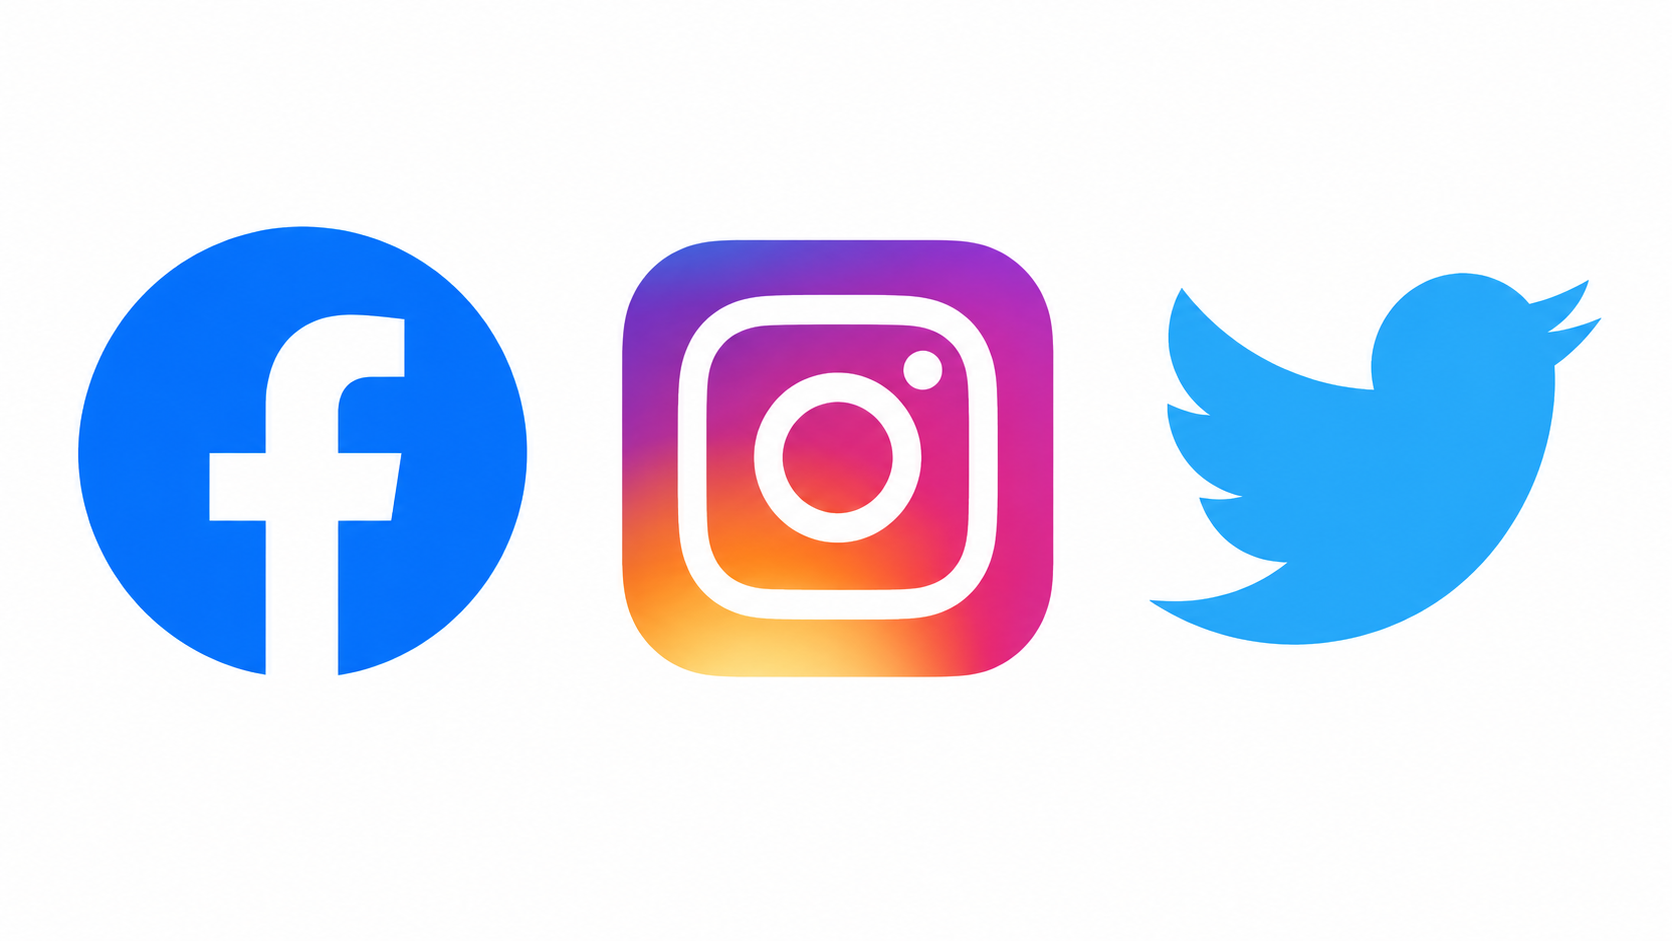

#**Colores**

**Esquemas de color**

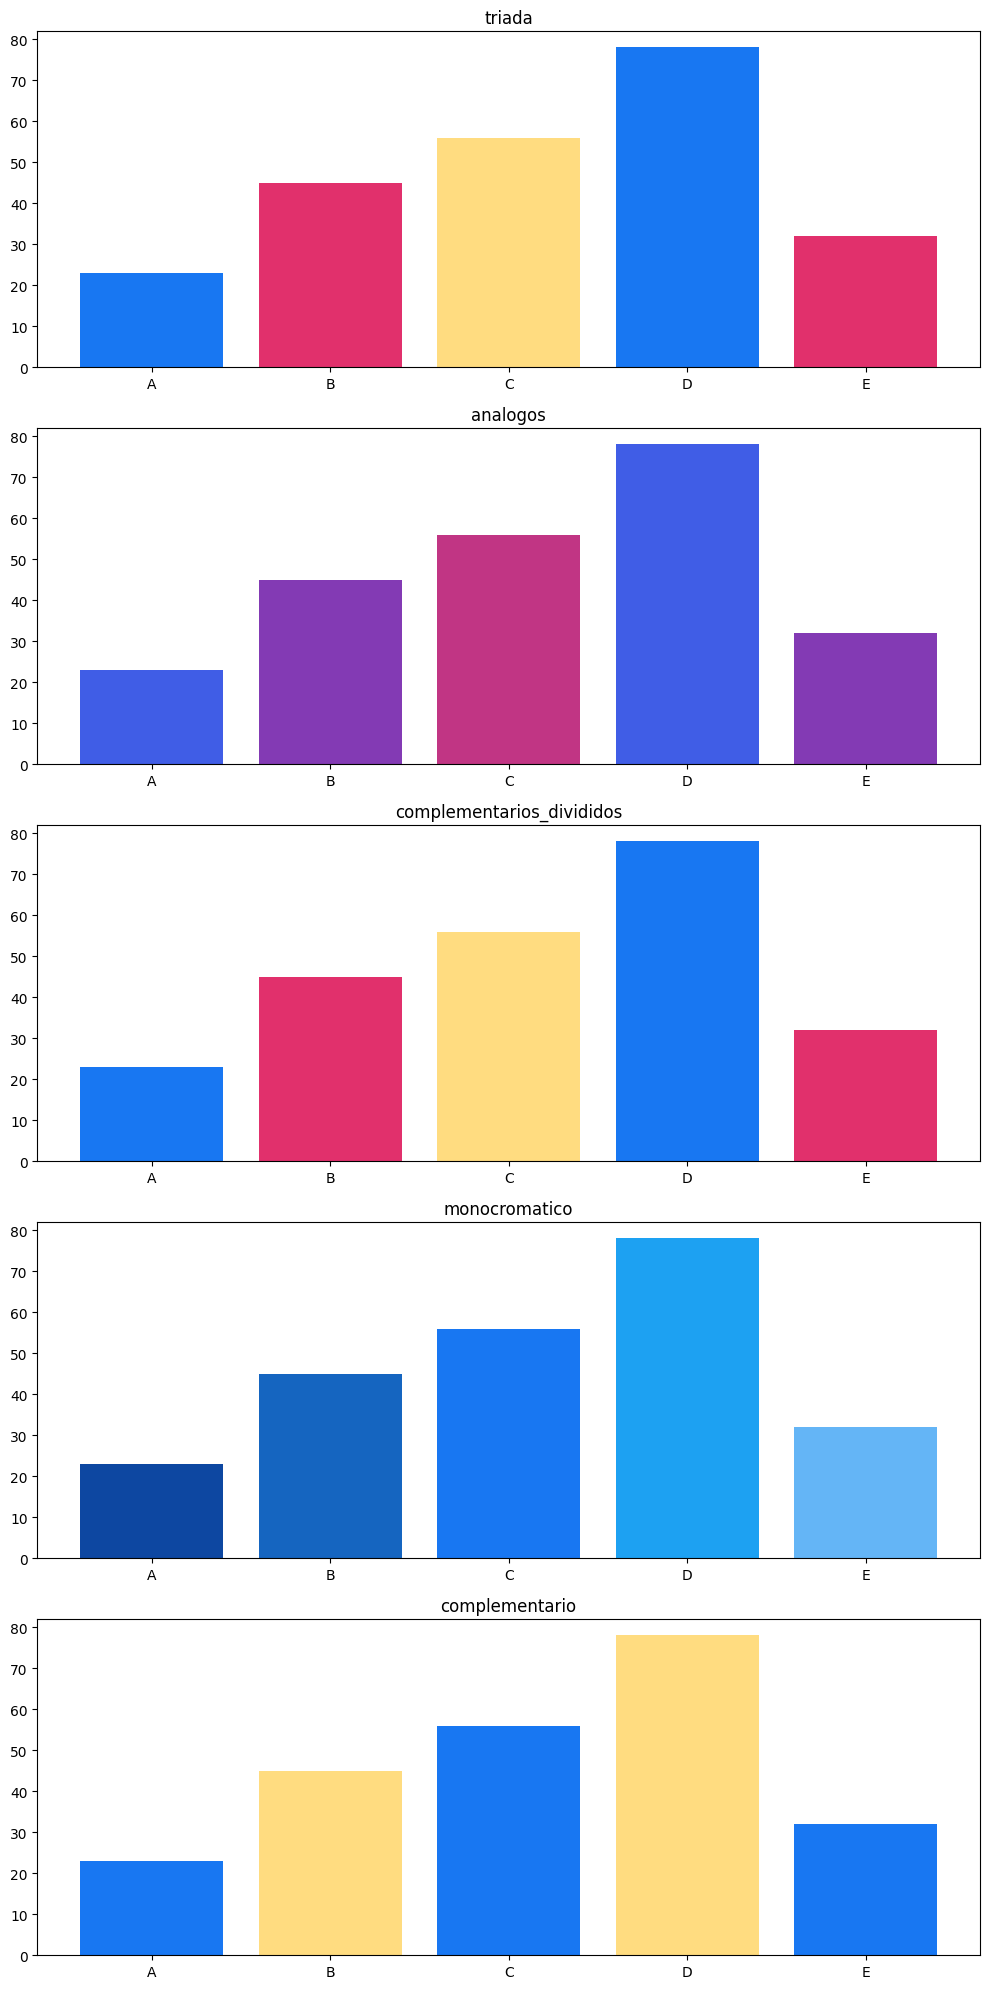

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Crear paletas de colores a usar en el dashboard
# Colores inspirados en Facebook, Instagram y Twitter

paletas = {
    'triada': ["#1877F2", "#E1306C", "#FFDC80"],
    'analogos': ["#405DE6", "#833AB4", "#C13584"],
    'complementarios_divididos': ["#1877F2", "#E1306C", "#FFDC80"],
    'monocromatico': ["#0D47A1", "#1565C0", "#1877F2", "#1DA1F2", "#64B5F6", "#90CAF9", "#BBDEFB", "#E3F2FD"],
    'complementario': ["#1877F2", "#FFDC80"]
}

# Datos
categorias = ['A', 'B', 'C', 'D', 'E']
valores = [23, 45, 56, 78, 32]

# Una figura con tantas filas como paletas
fig, axes = plt.subplots(len(paletas), 1, figsize=(10,20))

for i, (nombre_paleta, colores) in enumerate(paletas.items()):
    ax = axes[i]
    ax.bar(categorias, valores, color=colores)
    ax.set_title(nombre_paleta)

plt.tight_layout()
plt.show()

La paleta de colores está inspirada en los colores principales que se usan en la red social de Facebook, Instagram y Twitter. Se utilizaron tonos azules como base para transmitir confianza y tecnología. También se integraron colores cálidos como rosa, naranja y amarillo, inspirados en Instagram, para poder dar un contraste y una apariencia más visual. La paleta monocromática mantiene armonía con variaciones de azul, mientras que la triádica y complementaria permiten diferenciar mejor las categorías dentro de las gráficas.

**Gráficos con Plotly**

**Gráfico 1: Engagement total por plataforma**

In [ ]:
import plotly.express as px

# Crear columna de engagement total
df["engagement_total"] = df["likes"] + df["comments"] + df["shares"]

# Agrupar por plataforma
df_platform = df.groupby("platform", as_index=False)["engagement_total"].sum()

# Gráfico 1
fig1 = px.bar(
    df_platform,
    x="platform",
    y="engagement_total",
    color="platform",
    color_discrete_sequence=paletas["triada"],
    title="Engagement total por plataforma",
    labels={
        "platform": "Plataforma",
        "engagement_total": "Engagement total"
    },
    text="engagement_total",
    hover_data={
        "platform": True,
        "engagement_total": ":,"
    }
)

# Mejoras visuales
fig1.update_traces(
    texttemplate="%{text:,}",
    textposition="outside"
)

fig1.update_layout(
    template="plotly_white",
    title_font_size=22,
    title_x=0.5,
    xaxis_title="Plataforma",
    yaxis_title="Engagement total",
    font=dict(size=13),
    showlegend=False,
    height=500
)

# Anotación
fig1.add_annotation(
    text="El engagement total se calcula sumando likes, comentarios y shares.",
    xref="paper",
    yref="paper",
    x=0.5,
    y=-0.18,
    showarrow=False,
    font=dict(size=12)
)

fig1.show()

Muestra el engagement total generado por cada plataforma, considerando la suma de likes, comentarios y compartidos. La visualización permite comparar de forma directa qué red social concentra mayor interacción dentro del dataset. Se utilizó un esquema de color triádico para diferenciar claramente cada plataforma y facilitar la lectura visual. Este análisis es útil para identificar en qué canal existe mayor respuesta del público y dónde podría enfocarse una estrategia de contenido digital.

**Gráfico 2: Relación entre likes y comentarios por plataforma**

In [ ]:
fig2 = px.scatter(
    df,
    x="likes",
    y="comments",
    color="platform",
    size="shares",
    marginal_x="rug",
    marginal_y="rug",
    color_discrete_sequence=paletas["analogos"],
    title="Relación entre likes y comentarios por plataforma",
    labels={
        "likes": "Likes",
        "comments": "Comentarios",
        "platform": "Plataforma",
        "shares": "Compartidos"
    },
    hover_data={
        "post_id": True,
        "platform": True,
        "post_type": True,
        "likes": ":,",
        "comments": ":,",
        "shares": ":,",
        "sentiment_score": ":.2f"
    }
)

# Mejoras visuales
fig2.update_traces(
    marker=dict(
        opacity=0.75,
        line=dict(width=0.5, color="white")
    )
)

fig2.update_layout(
    template="plotly_white",
    title_font_size=22,
    title_x=0.5,
    xaxis_title="Número de likes",
    yaxis_title="Número de comentarios",
    font=dict(size=13),
    height=550,
    legend_title_text="Plataforma"
)

# Anotación
fig2.add_annotation(
    text="El tamaño de cada punto representa la cantidad de shares de la publicación.",
    xref="paper",
    yref="paper",
    x=0.5,
    y=-0.18,
    showarrow=False,
    font=dict(size=12)
)

fig2.show()

Analiza la relación entre likes y comentarios en las publicaciones de redes sociales. Cada punto representa una publicación, el color identifica la plataforma y el tamaño del punto muestra la cantidad de veces que fue compartida. Se utilizó un gráfico de dispersión con rugs para observar mejor la concentración de datos en ambos ejes. Esta visualización permite identificar si existe una relación positiva entre el número de likes y comentarios, además de detectar publicaciones con alto nivel de interacción.

**Gráfico 3: Engagement promedio por día de la semana**

In [ ]:
# Gráfico 3: Engagement promedio por día de publicación

# Crear columna de engagement total si todavía no existe
df["engagement_total"] = df["likes"] + df["comments"] + df["shares"]

# Orden correcto de los días de la semana
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Agrupar por día
df_day = df.groupby("post_day", as_index=False)["engagement_total"].mean()

# Reordenar los días
df_day["post_day"] = pd.Categorical(df_day["post_day"], categories=orden_dias, ordered=True)
df_day = df_day.sort_values("post_day")

# Identificar el día con mayor engagement promedio
dia_top = df_day.loc[df_day["engagement_total"].idxmax()]

# Gráfico 3
fig3 = px.line(
    df_day,
    x="post_day",
    y="engagement_total",
    markers=True,
    title="Engagement promedio por día de publicación",
    labels={
        "post_day": "Día de publicación",
        "engagement_total": "Engagement promedio"
    },
    color_discrete_sequence=[paletas["complementario"][0]],
    hover_data={
        "post_day": True,
        "engagement_total": ":.2f"
    }
)

# Mejoras visuales
fig3.update_traces(
    line=dict(width=4),
    marker=dict(size=10, line=dict(width=1, color="white"))
)

fig3.update_layout(
    template="plotly_white",
    title_font_size=22,
    title_x=0.5,
    xaxis_title="Día de publicación",
    yaxis_title="Engagement promedio",
    font=dict(size=13),
    height=500
)

# Anotación del punto más alto
fig3.add_annotation(
    x=dia_top["post_day"],
    y=dia_top["engagement_total"],
    text="Mayor engagement promedio",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-40,
    font=dict(size=12)
)

# Nota inferior
fig3.add_annotation(
    text="El engagement promedio se calcula con la suma de likes, comentarios y shares por publicación.",
    xref="paper",
    yref="paper",
    x=0.5,
    y=-0.20,
    showarrow=False,
    font=dict(size=12)
)

fig3.show()

Muestra el engagement promedio por día de publicación, considerando la suma de likes, comentarios y compartidos. La visualización permite identificar qué días de la semana generan una mayor respuesta del público. Se utilizó un gráfico de línea porque el eje representa una secuencia temporal semanal, lo que facilita observar variaciones y posibles patrones de comportamiento. Además, se agregó una anotación para destacar el día con mayor engagement promedio, ayudando a interpretar rápidamente el punto más relevante del análisis.

**Gráfica 4: Distribución de tipos de publicación por plataforma**

In [ ]:
# Agrupar por plataforma y tipo de publicación
df_post_type = df.groupby(["platform", "post_type"], as_index=False).size()
df_post_type = df_post_type.rename(columns={"size": "cantidad_publicaciones"})

# Identificar el tipo de publicación más frecuente
top_post_type = df_post_type.loc[df_post_type["cantidad_publicaciones"].idxmax()]

# Gráfico 4
fig4 = px.bar(
    df_post_type,
    x="platform",
    y="cantidad_publicaciones",
    color="post_type",
    title="Distribución de tipos de publicación por plataforma",
    labels={
        "platform": "Plataforma",
        "cantidad_publicaciones": "Cantidad de publicaciones",
        "post_type": "Tipo de publicación"
    },
    color_discrete_sequence=paletas["complementarios_divididos"],
    hover_data={
        "platform": True,
        "post_type": True,
        "cantidad_publicaciones": True
    }
)

# Mejoras visuales
fig4.update_layout(
    template="plotly_white",
    title_font_size=22,
    title_x=0.5,
    xaxis_title="Plataforma",
    yaxis_title="Cantidad de publicaciones",
    font=dict(size=13),
    height=520,
    legend_title_text="Tipo de publicación",
    barmode="stack"
)

# Anotación
fig4.add_annotation(
    text=f"El tipo de publicación más frecuente es {top_post_type['post_type']} en {top_post_type['platform']}.",
    xref="paper",
    yref="paper",
    x=0.5,
    y=-0.20,
    showarrow=False,
    font=dict(size=12)
)

fig4.show()

Este gráfico muestra la distribución de los tipos de publicación dentro de cada plataforma. Cada barra representa una red social y sus segmentos indican cuántas publicaciones corresponden a cada formato de contenido. Se utilizó un gráfico de barras apiladas porque permite comparar tanto el volumen total de publicaciones como la composición interna por tipo de post. Esta visualización ayuda a identificar qué formatos predominan en cada plataforma y puede orientar decisiones sobre qué tipo de contenido conviene reforzar en la estrategia digital.

**Gráfica 5: Engagement promedio por tipo de publicación**

In [ ]:
# Gráfica 5: Engagement promedio por tipo de publicación

# Crear columna de engagement total
df["engagement_total"] = df["likes"] + df["comments"] + df["shares"]

# Agrupar por tipo de publicación
df_post_engagement = df.groupby("post_type", as_index=False)["engagement_total"].mean()

# Ordenar de mayor a menor
df_post_engagement = df_post_engagement.sort_values(
    "engagement_total",
    ascending=False
)

# Identificar el tipo de publicación con mayor engagement
top_post = df_post_engagement.iloc[0]

# Gráfico 5
fig5 = px.bar(
    df_post_engagement,
    x="post_type",
    y="engagement_total",
    color="post_type",
    title="Engagement promedio por tipo de publicación",
    labels={
        "post_type": "Tipo de publicación",
        "engagement_total": "Engagement promedio"
    },
    color_discrete_sequence=paletas["monocromatico"],
    text="engagement_total",
    hover_data={
        "post_type": True,
        "engagement_total": ":.2f"
    }
)

# Mejoras visuales
fig5.update_traces(
    texttemplate="%{text:.1f}",
    textposition="outside",
    marker_line_width=0.5,
    marker_line_color="white"
)

fig5.update_layout(
    template="plotly_white",
    title_font_size=22,
    title_x=0.5,
    xaxis_title="Tipo de publicación",
    yaxis_title="Engagement promedio",
    font=dict(size=13),
    height=520,
    showlegend=False,
    bargap=0.30
)

# Anotación
fig5.add_annotation(
    x=top_post["post_type"],
    y=top_post["engagement_total"],
    text="Mayor engagement promedio",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-40,
    font=dict(size=12)
)

# Nota inferior
fig5.add_annotation(
    text="El engagement promedio se calcula sumando likes, comentarios y shares por publicación.",
    xref="paper",
    yref="paper",
    x=0.5,
    y=-0.18,
    showarrow=False,
    font=dict(size=12)
)

fig5.show()

Es el engagement promedio generado por cada tipo de publicación, considerando la suma de likes, comentarios y compartidos. Se utilizó una gráfica de barras porque permite comparar de forma directa qué formato de contenido obtiene mayor respuesta del público. La paleta monocromática mantiene una estética limpia y coherente, mientras que la anotación destaca el tipo de publicación con mejor desempeño. Esta visualización es útil para identificar qué formatos pueden ser más efectivos dentro de una estrategia de contenido digital.

**Gráfica 6: Top 10 publicaciones con mayor engagement**

In [ ]:
# Gráfica 6: Top 10 publicaciones con mayor engagement

# Crear columna de engagement total
df["engagement_total"] = df["likes"] + df["comments"] + df["shares"]

# Crear etiqueta corta para identificar cada publicación
df["post_label"] = "Post " + df["post_id"].astype(str)

# Seleccionar top 10 publicaciones con mayor engagement
df_top_posts = df.sort_values(
    "engagement_total",
    ascending=False
).head(10)

# Ordenar para que la barra más alta quede arriba
df_top_posts = df_top_posts.sort_values("engagement_total", ascending=True)

# Identificar publicación con mayor engagement
top_post = df_top_posts.loc[df_top_posts["engagement_total"].idxmax()]

# Gráfico 6
fig6 = px.bar(
    df_top_posts,
    x="engagement_total",
    y="post_label",
    color="platform",
    orientation="h",
    title="Top 10 publicaciones con mayor engagement",
    labels={
        "engagement_total": "Engagement total",
        "post_label": "Publicación",
        "platform": "Plataforma"
    },
    color_discrete_sequence=paletas["complementarios_divididos"],
    text="engagement_total",
    hover_data={
        "post_id": True,
        "platform": True,
        "post_type": True,
        "likes": ":,",
        "comments": ":,",
        "shares": ":,",
        "engagement_total": ":,"
    }
)

# Mejoras visuales
fig6.update_traces(
    texttemplate="%{text:,}",
    textposition="outside",
    marker_line_width=0.5,
    marker_line_color="white"
)

fig6.update_layout(
    template="plotly_white",
    title_font_size=22,
    title_x=0.5,
    xaxis_title="Engagement total",
    yaxis_title="Publicación",
    font=dict(size=13),
    height=560,
    legend_title_text="Plataforma",
    margin=dict(l=90, r=60, t=80, b=80)
)

# Anotación
fig6.add_annotation(
    x=top_post["engagement_total"],
    y=top_post["post_label"],
    text="Publicación con mayor engagement",
    showarrow=True,
    arrowhead=2,
    ax=-80,
    ay=-30,
    font=dict(size=12)
)

# Nota inferior
fig6.add_annotation(
    text="El engagement total se calcula sumando likes, comentarios y shares por publicación.",
    xref="paper",
    yref="paper",
    x=0.5,
    y=-0.16,
    showarrow=False,
    font=dict(size=12)
)

fig6.show()

Cada barra representa una publicación y el color indica la plataforma a la que pertenece. Se utilizó una gráfica de barras horizontales porque permite comparar rankings de forma clara y facilita la lectura de los identificadores de publicación. Además, los tooltips muestran el desglose de likes, comentarios y compartidos, lo que permite entender de dónde proviene el desempeño de cada publicación. Esta visualización es útil para identificar los contenidos con mejor rendimiento y analizar qué características comparten las publicaciones más exitosas.

**Gráfico 7: Distribución porcentual de publicaciones por plataforma**

In [ ]:
df_platform_count = df.groupby("platform", as_index=False).size()
df_platform_count = df_platform_count.rename(columns={"size": "cantidad_publicaciones"})

# Calcular porcentaje
df_platform_count["porcentaje"] = (
    df_platform_count["cantidad_publicaciones"] / df_platform_count["cantidad_publicaciones"].sum()
) * 100

# Identificar plataforma con mayor número de publicaciones
top_platform = df_platform_count.loc[df_platform_count["cantidad_publicaciones"].idxmax()]

# Gráfico 7
fig7 = px.pie(
    df_platform_count,
    names="platform",
    values="cantidad_publicaciones",
    hole=0.45,
    title="Distribución porcentual de publicaciones por plataforma",
    color="platform",
    color_discrete_sequence=paletas["triada"],
    hover_data=["cantidad_publicaciones", "porcentaje"]
)

# Mejoras visuales
fig7.update_traces(
    textposition="inside",
    textinfo="percent+label",
    pull=[0.06 if platform == top_platform["platform"] else 0
          for platform in df_platform_count["platform"]],
    marker=dict(
        line=dict(color="white", width=2)
    ),
    hovertemplate="<b>%{label}</b><br>" +
                  "Publicaciones: %{value}<br>" +
                  "Porcentaje: %{customdata[1]:.2f}%<extra></extra>"
)

fig7.update_layout(
    template="plotly_white",
    title_font_size=22,
    title_x=0.5,
    font=dict(size=13),
    height=520,
    legend_title_text="Plataforma"
)

# Texto central
fig7.add_annotation(
    text="Total<br>publicaciones",
    x=0.5,
    y=0.5,
    showarrow=False,
    font=dict(size=14)
)

# Nota inferior
fig7.add_annotation(
    text=f"La plataforma con mayor cantidad de publicaciones es {top_platform['platform']}.",
    xref="paper",
    yref="paper",
    x=0.5,
    y=-0.12,
    showarrow=False,
    font=dict(size=12)
)

fig7.show()

Este gráfico muestra la distribución porcentual de publicaciones por plataforma. Se utilizó una gráfica de dona porque permite visualizar de forma clara la proporción que representa cada red social dentro del total de publicaciones analizadas. La paleta triádica ayuda a diferenciar las plataformas de manera atractiva y equilibrada. Además, se resaltó ligeramente la plataforma con mayor cantidad de publicaciones para facilitar la interpretación visual. Esta gráfica es útil para entender en qué canales se concentra la actividad de contenido y si existe una distribución equilibrada o dominante entre plataformas.

**Gráfico 8: Distribución del engagement por plataforma**

In [ ]:
# Crear columna de engagement total
df["engagement_total"] = df["likes"] + df["comments"] + df["shares"]

# Calcular mediana por plataforma para anotación
df_mediana = df.groupby("platform", as_index=False)["engagement_total"].median()

# Identificar plataforma con mayor mediana de engagement
top_mediana = df_mediana.loc[df_mediana["engagement_total"].idxmax()]

# Gráfico 8
fig8 = px.box(
    df,
    x="platform",
    y="engagement_total",
    color="platform",
    points="all",
    title="Distribución del engagement por plataforma",
    labels={
        "platform": "Plataforma",
        "engagement_total": "Engagement total"
    },
    color_discrete_sequence=paletas["triada"],
    hover_data={
        "post_id": True,
        "platform": True,
        "post_type": True,
        "likes": ":,",
        "comments": ":,",
        "shares": ":,",
        "engagement_total": ":,"
    }
)

# Mejoras visuales
fig8.update_traces(
    marker=dict(
        opacity=0.55,
        size=6,
        line=dict(width=0.5, color="white")
    )
)

fig8.update_layout(
    template="plotly_white",
    title_font_size=22,
    title_x=0.5,
    xaxis_title="Plataforma",
    yaxis_title="Engagement total",
    font=dict(size=13),
    height=550,
    showlegend=False
)

# Anotación
fig8.add_annotation(
    x=top_mediana["platform"],
    y=top_mediana["engagement_total"],
    ax=0,
    ay=-50,
    font=dict(size=12)
)

# Nota inferior
fig8.add_annotation(
    text="Cada punto representa una publicación; la caja resume la distribución del engagement en cada plataforma.",
    xref="paper",
    yref="paper",
    x=0.5,
    y=-0.18,
    showarrow=False,
    font=dict(size=12)
)

fig8.show()

Se utilizó un boxplot porque permite observar la mediana, la variabilidad y posibles valores atípicos dentro de cada red social. Además, se agregaron los puntos individuales para visualizar cada publicación y comprender mejor la dispersión de los datos. Esta visualización ayuda a identificar qué plataforma mantiene un desempeño más consistente y cuál presenta publicaciones con engagement excepcionalmente alto.

**Gráfico 9: Composición del engagement por plataforma y tipo de publicación**

In [ ]:
# Crear columna de engagement total
df["engagement_total"] = df["likes"] + df["comments"] + df["shares"]

# Agrupar por plataforma y tipo de publicación
df_treemap = df.groupby(
    ["platform", "post_type"],
    as_index=False
).agg({
    "engagement_total": "sum",
    "likes": "sum",
    "comments": "sum",
    "shares": "sum",
    "post_id": "count"
})

# Renombrar columna de conteo
df_treemap = df_treemap.rename(columns={"post_id": "cantidad_publicaciones"})

# Identificar combinación con mayor engagement
top_combo = df_treemap.loc[df_treemap["engagement_total"].idxmax()]

# Gráfico 9
fig9 = px.treemap(
    df_treemap,
    path=["platform", "post_type"],
    values="engagement_total",
    color="platform",
    title="Composición del engagement por plataforma y tipo de publicación",
    color_discrete_sequence=paletas["complementarios_divididos"],
    hover_data={
        "engagement_total": ":,",
        "likes": ":,",
        "comments": ":,",
        "shares": ":,",
        "cantidad_publicaciones": True
    }
)

# Mejoras visuales
fig9.update_traces(
    textinfo="label+value+percent parent",
    marker=dict(
        line=dict(color="white", width=2)
    ),
    hovertemplate="<b>%{label}</b><br>" +
                  "Engagement total: %{value:,}<br>" +
                  "Porcentaje dentro del grupo: %{percentParent:.2%}<br>" +
                  "<extra></extra>"
)

fig9.update_layout(
    template="plotly_white",
    title_font_size=22,
    title_x=0.5,
    font=dict(size=13),
    height=580,
    margin=dict(t=80, l=30, r=30, b=90)
)

# Anotación
fig9.add_annotation(
    text=f"La combinación con mayor engagement es {top_combo['post_type']} en {top_combo['platform']}.",
    xref="paper",
    yref="paper",
    x=0.5,
    y=-0.08,
    showarrow=False,
    font=dict(size=12)
)

fig9.show()

Se utilizó un treemap porque permite visualizar jerarquías y proporciones de manera compacta, mostrando qué combinaciones concentran mayor interacción. El tamaño de cada rectángulo representa el engagement total, calculado como la suma de likes, comentarios y compartidos. Esta visualización ayuda a identificar qué formatos funcionan mejor dentro de cada plataforma y permite orientar la estrategia hacia las combinaciones con mayor rendimiento.

**Gráfico 10: Engagement promedio por hora de publicación**

In [ ]:
# Crear columna de engagement total
df["engagement_total"] = df["likes"] + df["comments"] + df["shares"]

# Convertir post_time a formato de hora
df["post_time"] = pd.to_datetime(df["post_time"], errors="coerce")

# Extraer la hora de publicación
df["hora_publicacion"] = df["post_time"].dt.hour

# Agrupar por hora
df_hora = df.groupby("hora_publicacion", as_index=False)["engagement_total"].mean()

# Quitar valores nulos por si alguna hora no se convirtió bien
df_hora = df_hora.dropna()

# Identificar la hora con mayor engagement promedio
hora_top = df_hora.loc[df_hora["engagement_total"].idxmax()]

# Gráfico 10
fig10 = px.area(
    df_hora,
    x="hora_publicacion",
    y="engagement_total",
    title="Engagement promedio por hora de publicación",
    labels={
        "hora_publicacion": "Hora de publicación",
        "engagement_total": "Engagement promedio"
    },
    color_discrete_sequence=[paletas["complementario"][0]],
    hover_data={
        "hora_publicacion": True,
        "engagement_total": ":.2f"
    }
)

# Agregar línea con puntos
fig10.add_scatter(
    x=df_hora["hora_publicacion"],
    y=df_hora["engagement_total"],
    mode="lines+markers",
    line=dict(width=4, color=paletas["complementario"][0]),
    marker=dict(size=8, color=paletas["complementario"][1], line=dict(width=1, color="white")),
    name="Engagement promedio"
)

# Mejoras visuales
fig10.update_layout(
    template="plotly_white",
    title_font_size=22,
    title_x=0.5,
    xaxis_title="Hora de publicación",
    yaxis_title="Engagement promedio",
    font=dict(size=13),
    height=520,
    showlegend=False,
    xaxis=dict(
        tickmode="linear",
        dtick=1
    )
)

# Anotación de la mejor hora
fig10.add_annotation(
    x=hora_top["hora_publicacion"],
    y=hora_top["engagement_total"],
    text="Hora con mayor engagement promedio",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-45,
    font=dict(size=12)
)

# Nota inferior
fig10.add_annotation(
    text="El engagement promedio se calcula sumando likes, comentarios y shares por publicación.",
    xref="paper",
    yref="paper",
    x=0.5,
    y=-0.18,
    showarrow=False,
    font=dict(size=12)
)

fig10.show()

Muestra el engagement promedio según la hora de publicación. Se utilizó una gráfica de área con línea porque permite observar la variación del rendimiento a lo largo del día y detectar posibles horarios con mayor interacción. El engagement se calculó sumando likes, comentarios y compartidos por publicación. Además, se agregó una anotación para resaltar la hora con mayor engagement promedio. Esta visualización es útil para tomar decisiones estratégicas sobre los mejores horarios para publicar contenido en redes sociales.